<a href="https://colab.research.google.com/github/ashon333/comp8420-nlp-group-Q/blob/main/COMP8420_Ecommerce_NLP_Colab%20(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP8420 – Use Case 6: E-commerce Intelligent System
## Advanced NLP/LLM Project – Google Colab

**Advanced Techniques Implemented:**
1. LLM Foundation Model (Llama 3.1 via Groq)
2. Retrieval Augmented Generation (RAG)
3. Prompting Engineering + Chain-of-Thought (CoT)
4. Agentic Design

**Dataset:** Datafiniti Amazon Consumer Reviews (~67,000 reviews)



## ⚙️ Step 1 – Install Dependencies
Run this once at the start of every Colab session.

In [22]:
!pip install groq sentence-transformers chromadb scikit-learn matplotlib seaborn -q
print('All packages installed.')

All packages installed.


## ⚙️ Step 2 – Groq API Key
Get your **free** key at https://console.groq.com → API Keys → Create
Paste it below. Do not share this key publicly.

In [23]:
from groq import Groq

GROQ_API_KEY = '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'
client     = Groq(api_key=GROQ_API_KEY)
MODEL_NAME = 'llama-3.1-8b-instant'

def call_llama(prompt, system_prompt=None, temperature=0.3):
    """
    Sends a prompt to Llama 3.1 via Groq cloud API.
    Used by all 4 advanced technique sections below.
    """
    messages = []
    if system_prompt:
        messages.append({'role': 'system', 'content': system_prompt})
    messages.append({'role': 'user', 'content': prompt})
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=temperature,
            max_tokens=1024
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f'Groq API error: {e}')
        return None

print(f'Groq ready. Model: {MODEL_NAME}')


Groq ready. Model: llama-3.1-8b-instant


## ⚙️ Step 3 – Load Data from Google Drive
Upload your 3 CSV files to a folder in Google Drive first.
Then update `DATA_DIR` below to match your folder path.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

# ── Change this to your folder path ──────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/COMP8420_data/'
# ─────────────────────────────────────────────────────────────────────

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, re, json, warnings
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import chromadb
warnings.filterwarnings('ignore')

df1 = pd.read_csv(DATA_DIR + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')
df2 = pd.read_csv(DATA_DIR + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')
df3 = pd.read_csv(DATA_DIR + '1429_1.csv', low_memory=False)
print(f'Loaded: {len(df1)+len(df2)+len(df3):,} total reviews across 3 datasets')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 67,992 total reviews across 3 datasets


## ⚙️ Step 4 – Merge & Clean Data


In [25]:
# Columns that exist across all 3 datasets
common_cols = ['name', 'brand', 'categories', 'primaryCategories',
               'reviews.rating', 'reviews.text', 'reviews.title',
               'reviews.username', 'reviews.numHelpful', 'reviews.doRecommend']

def safe_select(df, cols):
    """Select only columns that exist in the dataframe."""
    return df[[c for c in cols if c in df.columns]].copy()

df_all = pd.concat([safe_select(d, common_cols) for d in [df1, df2, df3]], ignore_index=True)
df_all.rename(columns={
    'reviews.rating':      'rating',
    'reviews.text':        'review_text',
    'reviews.title':       'review_title',
    'reviews.username':    'username',
    'reviews.numHelpful':  'helpful_votes',
    'reviews.doRecommend': 'recommends'
}, inplace=True)

df_all.dropna(subset=['review_text', 'rating'], inplace=True)
df_all['rating']      = pd.to_numeric(df_all['rating'], errors='coerce')
df_all['review_text'] = df_all['review_text'].astype(str).str.strip()
df_all['name'] = df_all['name'].astype(str).str.strip()
df_all['name'] = df_all['name'].str.split(',,,').str[0].str.strip()
df_all = df_all[df_all['name'].str.lower() != 'nan']
df_all['word_count']  = df_all['review_text'].apply(lambda x: len(x.split()))
df_all.dropna(subset=['rating'], inplace=True)
df_all = df_all[df_all['word_count'] >= 10].reset_index(drop=True)

print(f'Combined dataset: {len(df_all):,} reviews | {df_all["name"].nunique()} unique products')
print(f'Rating distribution:')
print(df_all['rating'].value_counts().sort_index().to_string())

Combined dataset: 53,020 reviews | 111 unique products
Rating distribution:
rating
1.0     1188
2.0      888
3.0     2416
4.0    12919
5.0    35609


---
# Advanced Technique 1: LLM Foundation Model (Llama 3.1)

Uses Llama 3.1 as the core generation engine for:
- **Review summarisation** – balanced summary per product
- **Product description generation** – marketing copy from positive reviews
- **Business insight generation** – cross-product seller recommendations
- **Evaluation** – TF-IDF coverage + Unigram Recall (ROUGE-1 proxy)

In [26]:
# Select top 6 products by review count for analysis
top_products = df_all['name'].value_counts().head(6).index.tolist()
df_work      = df_all[df_all['name'].isin(top_products)].copy()

print('Selected products:')
for i, p in enumerate(top_products, 1):
    count = len(df_work[df_work['name'] == p])
    avg   = df_work[df_work['name'] == p]['rating'].mean()
    print(f'  {i}. {p[:65]:<65} | {count:>5} reviews | avg {avg:.2f}★')

Selected products:
  1. Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Ma | 10503 reviews | avg 4.45★
  2. AmazonBasics AAA Performance Alkaline Batteries (36 Count)        |  4275 reviews | avg 4.24★
  3. Echo (White)                                                      |  3179 reviews | avg 4.64★
  4. Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Pap |  3057 reviews | avg 4.75★
  5. Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proo |  2975 reviews | avg 4.52★
  6. All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes S |  2703 reviews | avg 4.58★


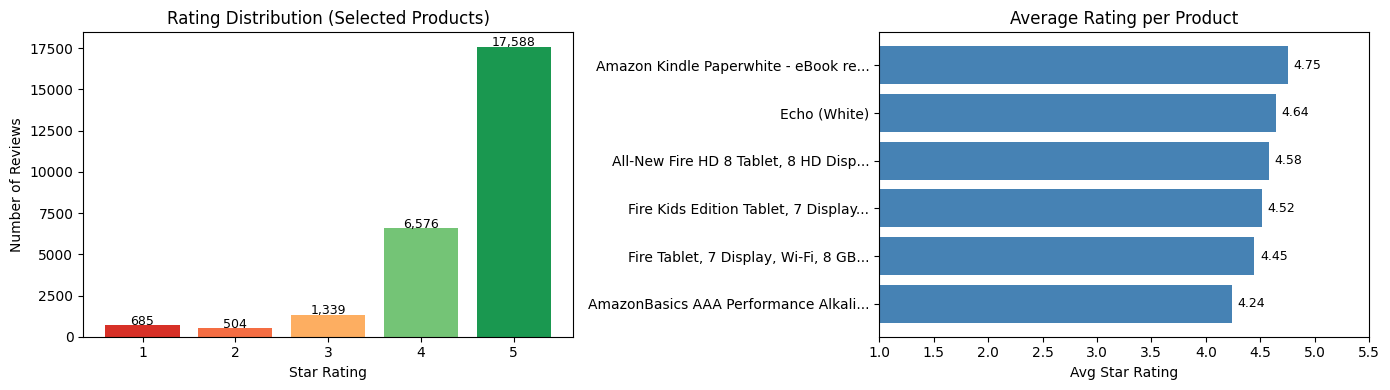

In [27]:
# Rating distribution overview
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rating_counts = df_work['rating'].value_counts().sort_index()
colors = ['#d73027','#f46d43','#fdae61','#74c476','#1a9850']
axes[0].bar(rating_counts.index.astype(float).astype(int), rating_counts.values, color=colors)
axes[0].set_title('Rating Distribution (Selected Products)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for x, y in zip(rating_counts.index.astype(float).astype(int), rating_counts.values):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', fontsize=9)

avg_ratings  = df_work.groupby('name')['rating'].mean().sort_values()
short_names  = [n[:35] + '...' if len(n) > 35 else n for n in avg_ratings.index]
axes[1].barh(short_names, avg_ratings.values, color='steelblue')
axes[1].set_title('Average Rating per Product')
axes[1].set_xlabel('Avg Star Rating')
axes[1].set_xlim(1, 5.5)
for i, v in enumerate(avg_ratings.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('nb1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.1 Review Summarisation

In [28]:
def sample_reviews_for_product(df, product_name, n_pos=4, n_neg=3, n_mid=2):
    """
    Samples a balanced mix of positive, negative and neutral reviews.
    Ensures the summary reflects the full range of customer opinions.
    """
    prod_df  = df[df['name'] == product_name].copy()
    positive = prod_df[prod_df['rating'] >= 4].sample(min(n_pos, len(prod_df[prod_df['rating'] >= 4])), random_state=42)
    negative = prod_df[prod_df['rating'] <= 2].sample(min(n_neg, len(prod_df[prod_df['rating'] <= 2])), random_state=42)
    middle   = prod_df[prod_df['rating'] == 3].sample(min(n_mid, len(prod_df[prod_df['rating'] == 3])), random_state=42)
    return pd.concat([positive, negative, middle])['review_text'].tolist()


def summarise_product_reviews(product_name, reviews_list):
    """Sends sampled reviews to Llama for structured 4-section summarisation."""
    truncated    = [r[:200] for r in reviews_list]
    reviews_block = '\n'.join([f'[Review {i+1}]: {r}' for i, r in enumerate(truncated)])
    system = 'You are a professional product analyst. Summarise customer reviews accurately and concisely.'
    prompt = f"""Product: {product_name[:80]}

Customer Reviews:
{reviews_block}

Write a structured summary with exactly these 4 sections:
1. Overall Sentiment
2. Key Positives
3. Key Negatives
4. Verdict (1-2 sentences)

Base your answer only on the reviews above."""
    return call_llama(prompt, system_prompt=system, temperature=0.3)


summaries = {}
for product in top_products:
    print(f'Summarising: {product[:60]}...')
    reviews          = sample_reviews_for_product(df_work, product)
    summary          = summarise_product_reviews(product, reviews)
    summaries[product] = summary
    display(Markdown(f'### {product[:70]}'))
    display(Markdown(summary or '*No summary*'))
    print('-' * 60)

Summarising: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer...


### Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta

**Summary of Customer Reviews**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with a slight leaning towards being positive. Out of the 9 reviews, 5 are positive, 3 are negative, and 1 is neutral.

**2. Key Positives**
Key positives of the Fire Tablet, 7 Display, Wi-Fi, 8 GB include:
- Great parental control/profile features for monitoring children.
- Good starter tablet for kids, making it easier to monitor online activity.
- Great reading experience with good resolution.
- Affordable price.
- Suitable for young children, with one customer's three-year-old enjoying it.

**3. Key Negatives**
Key negatives of the Fire Tablet, 7 Display, Wi-Fi, 8 GB include:
- Some customers experienced slow performance and unreliability.
- The tablet freezes up when watching movies or randomly.
- It no longer supports ultraviolet format, making it difficult for some customers to play movies.
- Sound quality is not as good as the older Kindle Fire HD model.

**4. Verdict**
The Fire Tablet, 7 Display, Wi-Fi, 8 GB is a suitable option for parents looking for a budget-friendly tablet for their children, with great parental control features. However, it may not be the best choice for customers seeking a high-performance tablet or those who require advanced features like ultraviolet format support.

------------------------------------------------------------
Summarising: AmazonBasics AAA Performance Alkaline Batteries (36 Count)...


### AmazonBasics AAA Performance Alkaline Batteries (36 Count)

...

**Summary of Customer Reviews**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with 4 positive reviews and 4 negative reviews. However, the positive reviews seem to outweigh the negative ones in terms of the number of customers who are satisfied with the product.

**2. Key Positives**
- The product is a great learning tool and fun to use with kids.
- It provides a sense of independence for children and gives parents peace of mind with parental controls.
- The kid-proof case is durable and protects the tablet from damage.
- The value of the cartoon membership is an added bonus.
- The tablet is suitable for young children and can be a good way to share quality time with them.

**3. Key Negatives**
- Some customers experienced issues with the tablet not turning on or charging.
- The product can be slow and may freeze.
- The touch screen quality is poor, making it difficult to navigate.
- The sound quality is lacking, and the picture quality is only "ok".
- Some customers were disappointed with the overall performance of the product.

**4. Verdict**
While the Fire Kids Edition Tablet has its drawbacks, it seems to be a suitable option for young children who are just starting to use tablets. However, parents may want to consider the potential for slow performance and poor touch screen quality before making a purchase.

------------------------------------------------------------
Summarising: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Inclu...


### All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Specia

**Product: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with 3 positive reviews and 5 negative reviews. However, if we consider the tone and language used, the positive reviews seem more enthusiastic and genuine, while the negative reviews are often more critical and disappointed.

**2. Key Positives**
- Easy to navigate and user-friendly, making it suitable for non-tech friendly individuals (Review 1).
- Many features and an upgrade from previous Kindle Fire models (Review 3).
- Works well and has no issues for some users (Review 4).
- Good value for the price (Review 9).

**3. Key Negatives**
- Some users experience charging issues (Review 5 and implied in Review 7).
- Limited functionality and performance compared to other tablets (Review 6).
- Slow performance and lagging issues (Review 8).
- Limited app selection compared to Google Play (Review 9).
- Some users experience internet connectivity issues and other problems (Review 7).

**4. Verdict**
The All-New Fire HD 8 Tablet seems to be a good option for those looking for a user-friendly and affordable tablet, but it may not meet the expectations of those seeking high-performance and a wide range of features.

------------------------------------------------------------


### 1.2 Product Description Generation

In [29]:
def generate_product_description(product_name, positive_reviews):
    """Generates marketing copy from top positive reviews."""
    review_block = '\n'.join([f'- {r[:180]}' for r in positive_reviews[:5]])
    system = 'You are a professional e-commerce copywriter. Write honest, engaging product descriptions.'
    prompt = f"""Product: {product_name[:80]}
What customers love:
{review_block}

Write a product description (100-150 words) for an Amazon listing.
Structure: Hook → 3-4 key features → call to action.
Do NOT invent features not mentioned."""
    return call_llama(prompt, system_prompt=system, temperature=0.5)


descriptions = {}
for product in top_products:
    pos_reviews = df_work[(df_work['name'] == product) & (df_work['rating'] >= 4)]['review_text'].head(5).tolist()
    if pos_reviews:
        print(f'Generating: {product[:55]}...')
        desc = generate_product_description(product, pos_reviews)
        descriptions[product] = desc
        display(Markdown(f'**{product[:70]}**'))
        display(Markdown(desc or '*No description*'))
        print()

Generating: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special ...


**Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta**

**Your Perfect Reading Companion: Fire Tablet, 7 Display, Wi-Fi, 8 GB**

Are you looking for a hassle-free eReader that's easy to use and packed with great features? Look no further. Our Fire Tablet, 7 Display, Wi-Fi, 8 GB is the perfect choice for readers of all ages.

**Key Features:**

* A 7-inch display that's perfect for reading, browsing, and streaming your favorite content
* 8 GB of storage to hold hundreds of books, and expandable storage options to keep you reading all day
* Long-lasting battery life, so you don't have to worry about daily charging
* A basic and easy-to-use interface that's perfect for readers who want to focus on their books

**Get your Fire Tablet today and start reading with ease!**


Generating: AmazonBasics AAA Performance Alkaline Batteries (36 Cou...


**AmazonBasics AAA Performance Alkaline Batteries (36 Count)**

...

**Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Cas**

**Introducing the Perfect Companion for Little Learners: Amazon Fire Kids Edition Tablet**

Is your child's curiosity and love for learning growing every day? Our Amazon Fire Kids Edition Tablet is here to fuel their imagination and keep them entertained for hours. This 7-inch tablet features:

- 16 GB of storage, perfect for storing their favorite games, e-books, and educational apps
- A kid-proof case to protect against drops and bumps, giving you peace of mind
- Wi-Fi connectivity for seamless access to thousands of child-friendly e-books, TV shows, games, and educational apps
- A simple and intuitive interface that's easy for little hands to navigate

Give your child the gift of endless learning and fun with the Amazon Fire Kids Edition Tablet. Order now and discover a world of possibilities!


Generating: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - ...


**All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Specia**

**Unlock a World of Entertainment and Learning with the All-New Fire HD 8 Tablet**

Are you looking for a reliable and affordable tablet for yourself or a loved one? Look no further than the All-New Fire HD 8 Tablet. With its 8 HD display, you'll enjoy crisp and vibrant visuals that bring your favorite shows, movies, and games to life.

This powerful tablet is perfect for beginners and experienced users alike, offering a seamless entertainment experience. Plus, with Amazon's parental controls, you can easily monitor and control what content your children access, giving you peace of mind.

As a Prime Member, you'll get the most out of your Fire HD 8 Tablet, with easy access to all your favorite Amazon content. Upgrade your tablet experience today and discover a world of endless entertainment and learning possibilities. **Get yours now and start exploring!**

### 1.3 Cross-Product Business Insights

In [30]:
def generate_business_insights(summaries_dict, df_stats):
    """Asks Llama for actionable insights across all product summaries."""
    block = ''
    for prod, summ in summaries_dict.items():
        avg_r = df_stats[df_stats['name'] == prod]['rating'].mean()
        count = len(df_stats[df_stats['name'] == prod])
        block += f'\nProduct: {prod[:60]}\nAvg Rating: {avg_r:.2f} ({count} reviews)\nSummary: {(summ or "")[:400]}\n'
    system = 'You are a senior e-commerce business analyst.'
    prompt = f"""Review summaries for Amazon products:
{block}

Provide:
1. Top 3 recurring complaints across all products
2. Top 3 things customers consistently praise
3. Products at risk (low ratings / high complaints)
4. Three specific actionable seller recommendations
5. One market opportunity from the data"""
    return call_llama(prompt, system_prompt=system, temperature=0.3)

print('Generating business insights...')
insights = generate_business_insights(summaries, df_work)
display(Markdown('## Business Intelligence Report'))
display(Markdown(insights or '*No insights*'))

Generating business insights...


## Business Intelligence Report

**Analysis and Recommendations**

**1. Top 3 Recurring Complaints Across All Products:**

1. **Battery Life/Performance Issues**: Several products, including the Fire Tablet, Fire Kids Edition Tablet, and AmazonBasics AAA Performance Alkaline Batteries, have customers complaining about battery life, performance, or longevity issues.
2. **Parental Controls/Child Safety Concerns**: The Fire Tablet and Fire Kids Edition Tablet have customers expressing concerns about parental controls, child safety, and monitoring features.
3. **Quality Control Issues**: The AmazonBasics AAA Performance Alkaline Batteries have customers complaining about quality control issues, such as leakage, corrosion, or inconsistent performance.

**2. Top 3 Things Customers Consistently Praise:**

1. **Ease of Use**: Many products, including the Echo, Fire Tablet, and Fire Kids Edition Tablet, have customers praising the ease of use and intuitive interface.
2. **Affordability**: The AmazonBasics AAA Performance Alkaline Batteries and Fire Tablet have customers appreciating the affordable price point.
3. **Convenience**: The Echo, Fire Tablet, and Fire Kids Edition Tablet have customers praising the convenience of the products, including features like voice control, parental controls, and access to a wide range of content.

**3. Products at Risk (Low Ratings / High Complaints):**

1. **AmazonBasics AAA Performance Alkaline Batteries**: With an average rating of 4.24 and numerous complaints about quality control issues, this product is at risk of losing customer trust.
2. **Fire Kids Edition Tablet**: With a mixed overall sentiment and complaints about parental controls and child safety, this product may require additional attention to address customer concerns.
3. **All-New Fire HD 8 Tablet**: With a mixed overall sentiment and complaints about battery life and performance, this product may require improvements to meet customer expectations.

**4. Three Specific Actionable Seller Recommendations:**

1. **Improve Quality Control for AmazonBasics AAA Performance Alkaline Batteries**: Conduct regular quality checks and implement measures to prevent leakage, corrosion, and inconsistent performance.
2. **Enhance Parental Controls for Fire Kids Edition Tablet**: Develop more robust parental controls and child safety features to address customer concerns and improve the overall user experience.
3. **Optimize Battery Life for All-New Fire HD 8 Tablet**: Conduct thorough testing and optimization to improve battery life and performance, addressing customer complaints and concerns.

**5. One Market Opportunity from the Data:**

**Expanding the Echo Product Line with Enhanced Features**: Based on customer praise for the Echo's ease of use, convenience, and wide range of functions, there is an opportunity to expand the Echo product line with enhanced features, such as improved voice control, enhanced smart home integration, or additional skills and capabilities. This could help Amazon capture a larger share of the smart speaker market and increase customer loyalty.

### 1.4 Evaluation – TF-IDF Coverage & Unigram Recall

,Product,Total Reviews,Avg Rating,TF-IDF Coverage,Unigram Recall,Summary Words
0,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Include",10503,4.45,0.2608,0.3111,211
1,AmazonBasics AAA Performance Alkaline Batteri,4275,4.24,0.3259,0.2121,213
2,Echo (White),3179,4.64,0.2455,0.2237,215
3,Amazon Kindle Paperwhite - eBook reader - 4 G,3057,4.75,0.1606,0.1739,152
4,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 1",2975,4.52,0.2404,0.2721,235
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi",2703,4.58,0.1502,0.2241,211


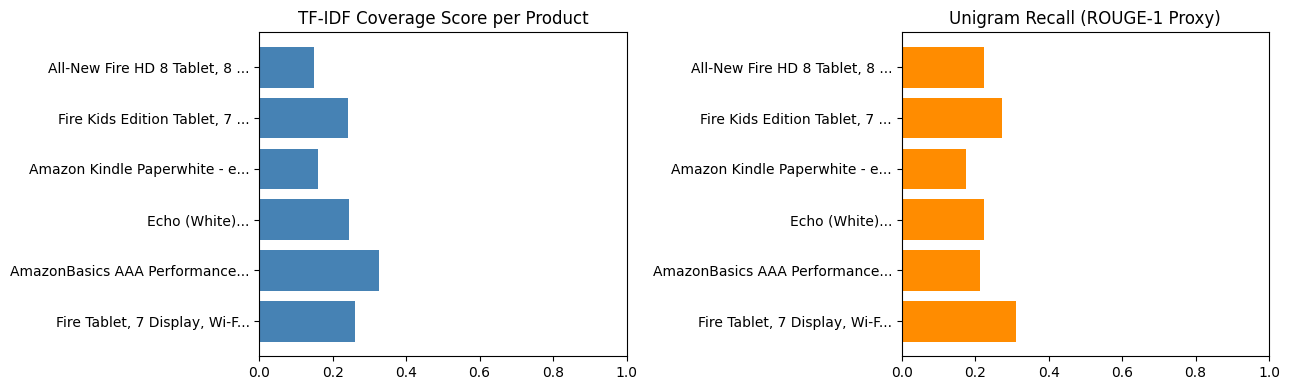

LLM Foundation evaluation complete.


In [31]:
def tfidf_coverage(original_reviews, summary):
    """TF-IDF cosine similarity between reviews and summary. Proxy for content coverage."""
    original_text = ' '.join(original_reviews)
    if not summary or not original_text: return 0.0
    vec = TfidfVectorizer(stop_words='english', max_features=500)
    try:
        mat = vec.fit_transform([original_text, summary])
        return round(float(cosine_similarity(mat[0:1], mat[1:2])[0][0]), 4)
    except: return 0.0

def unigram_recall(original_reviews, summary):
    """Fraction of review words appearing in summary. Proxy for ROUGE-1 recall."""
    if not summary: return 0.0
    orig_words    = set(' '.join(original_reviews).lower().split())
    summ_words    = set(summary.lower().split())
    return round(len(orig_words & summ_words) / len(orig_words) if orig_words else 0, 4)

eval_rows = []
for product in top_products:
    sampled = sample_reviews_for_product(df_work, product)
    summary = summaries.get(product, '')
    eval_rows.append({
        'Product':         product[:45],
        'Total Reviews':   len(df_work[df_work['name'] == product]),
        'Avg Rating':      round(df_work[df_work['name'] == product]['rating'].mean(), 2),
        'TF-IDF Coverage': tfidf_coverage(sampled, summary),
        'Unigram Recall':  unigram_recall(sampled, summary),
        'Summary Words':   len(summary.split()) if summary else 0
    })

eval_df1 = pd.DataFrame(eval_rows)
display(eval_df1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
short = [p[:28] + '...' for p in eval_df1['Product']]
axes[0].barh(short, eval_df1['TF-IDF Coverage'], color='steelblue')
axes[0].set_title('TF-IDF Coverage Score per Product')
axes[0].set_xlim(0, 1)
axes[1].barh(short, eval_df1['Unigram Recall'], color='darkorange')
axes[1].set_title('Unigram Recall (ROUGE-1 Proxy)')
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.savefig('eval_llm_foundation.png', dpi=150, bbox_inches='tight')
plt.show()
print('LLM Foundation evaluation complete.')

---
# Advanced Technique 2: Retrieval Augmented Generation (RAG)

Builds a **ChromaDB vector store** from real review data.
For each query, retrieves the most semantically relevant review chunks
and passes them as context to Llama — grounding answers in actual customer language.

- Embedding model: `all-MiniLM-L6-v2` (384-dim dense vectors)
- Comparison: RAG answer vs baseline (no retrieval)

In [32]:
def build_rag_documents(df, top_n_products=8, reviews_per_product=40):
    """
    Builds two document types per product:
    1. Product stats (avg rating, review count, % positive)
    2. Individual review chunks (balanced positive/negative)
    """
    top_prods = df['name'].value_counts().head(top_n_products).index.tolist()
    documents = []
    for product in top_prods:
        prod_df    = df[df['name'] == product].copy()
        avg_rating = prod_df['rating'].mean()
        total      = len(prod_df)
        pct_pos    = (prod_df['rating'] >= 4).mean() * 100
        cat = prod_df['primaryCategories'].dropna().iloc[0] if 'primaryCategories' in prod_df and prod_df['primaryCategories'].notna().any() else 'Amazon'
        documents.append({
            'doc_id': f'stats_{product[:20].replace(" ","_")}',
            'doc_type': 'product_stats',
            'product': product,
            'text': f'Product: {product}. Category: {cat}. Total reviews: {total}. '
                    f'Average rating: {avg_rating:.2f}/5. Positive reviews: {pct_pos:.1f}%.'
        })
        pos_s = prod_df[prod_df['rating'] >= 4].sample(min(reviews_per_product//2, len(prod_df[prod_df['rating'] >= 4])), random_state=42)
        neg_s = prod_df[prod_df['rating'] <= 2].sample(min(reviews_per_product//4, len(prod_df[prod_df['rating'] <= 2])), random_state=42)
        for idx, row in pd.concat([pos_s, neg_s]).iterrows():
            documents.append({
                'doc_id': f'review_{idx}',
                'doc_type': 'review',
                'product': product,
                'text': f'Product: {product[:60]}. Rating: {row["rating"]}/5. Review: {str(row["review_text"])[:300]}'
            })
    return documents


print('Loading sentence embedding model...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print('Building RAG documents...')
rag_docs = build_rag_documents(df_all)

# Build ChromaDB vector store
chroma_client = chromadb.EphemeralClient()
try: chroma_client.delete_collection('amazon_reviews_kb')
except: pass
collection = chroma_client.create_collection('amazon_reviews_kb', metadata={'hnsw:space': 'cosine'})

texts     = [d['text']     for d in rag_docs]
ids       = [d['doc_id']   for d in rag_docs]
metadatas = [{'doc_type': d['doc_type'], 'product': d['product'][:80]} for d in rag_docs]

# Batch embed
BATCH, all_embs = 64, []
for i in range(0, len(texts), BATCH):
    all_embs.extend(embedder.encode(texts[i:i+BATCH]).tolist())
collection.add(documents=texts, embeddings=all_embs, ids=ids, metadatas=metadatas)
print(f'Vector store ready: {collection.count()} documents indexed')

Loading sentence embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building RAG documents...
Vector store ready: 248 documents indexed


In [33]:
def retrieve(query, top_k=5):
    """Retrieves top_k most semantically similar review chunks for a query."""
    q_emb   = embedder.encode([query]).tolist()
    results = collection.query(query_embeddings=q_emb, n_results=top_k)
    retrieved = []
    for doc, dist, meta in zip(results['documents'][0], results['distances'][0], results['metadatas'][0]):
        retrieved.append({'text': doc, 'similarity': round(1 - dist, 4), 'doc_type': meta['doc_type']})
    return retrieved


def rag_answer(query, top_k=5):
    """Full RAG pipeline: retrieve relevant chunks → build augmented prompt → Llama generates answer."""
    context_docs = retrieve(query, top_k)
    context_text = '\n\n'.join([f'[Source {i+1} | Similarity: {d["similarity"]}]\n{d["text"]}'
                                 for i, d in enumerate(context_docs)])
    system = 'You are an e-commerce analyst. Answer using ONLY the provided review context. Never fabricate facts.'
    prompt = f'Context:\n{context_text}\n\nQuestion: {query}\n\nAnswer:'
    return {'answer': call_llama(prompt, system_prompt=system, temperature=0.3), 'retrieved': context_docs}


def baseline_answer(query):
    """Baseline: Llama answers with no retrieved context."""
    return call_llama(query, system_prompt='You are an e-commerce assistant.', temperature=0.3)


# Run 5 test queries
test_queries = [
    'What do customers say about Fire tablet battery life?',
    'What are the most common complaints about Amazon Echo?',
    'Which product has the highest customer satisfaction and why?',
    'What do negative reviews say about Kindle Paperwhite?',
    'Are Amazon alkaline batteries considered good value for money?'
]

rag_eval_results = []
for query in test_queries:
    print(f'Query: {query}')
    rag_out  = rag_answer(query)
    base_out = baseline_answer(query)
    top_sim  = rag_out['retrieved'][0]['similarity'] if rag_out['retrieved'] else 0
    print(f'  Top similarity: {top_sim}')
    print(f'  RAG:      {(rag_out["answer"] or "")[:200]}')
    print(f'  Baseline: {(base_out or "")[:200]}\n')
    rag_eval_results.append({'query': query, 'rag_answer': rag_out['answer'],
                             'baseline_answer': base_out, 'top_similarity': top_sim,
                             'retrieved': rag_out['retrieved']})

Query: What do customers say about Fire tablet battery life?
  Top similarity: 0.6029
  RAG:      Based on the provided review context, there is no direct mention of customers discussing the battery life of the Fire tablet. However, there are a few reviews that mention issues with charging, which 
  Baseline: Based on customer reviews and feedback, here's what I found about Fire tablet battery life:

- Many customers have reported that the battery life of Fire tablets is generally good, but it can vary dep

Query: What are the most common complaints about Amazon Echo?
  Top similarity: 0.6296
  RAG:      Based on the provided reviews, the most common complaints about Amazon Echo are:

1. Randomly stopping sound when connected to a TV as a Bluetooth speaker (Source 1).
2. Cutting off by itself without 
  Baseline: Based on customer reviews and feedback, here are some of the most common complaints about Amazon Echo:

1. **Intermittent connectivity issues**: Some users experience dropped 

,Query,Top Similarity,RAG Specificity,Base Specificity,Groundedness
0,What do customers say about Fire table...,0.6029,0.6640,0.7500,0.1466
1,What are the most common complaints ab...,0.6296,0.6060,0.7837,0.1272
2,Which product has the highest customer...,0.4134,0.6272,0.8071,0.6195
3,What do negative reviews say about Kin...,0.8063,0.0000,0.7331,0.0000
4,Are Amazon alkaline batteries consider...,0.6587,0.7303,0.7767,0.4308


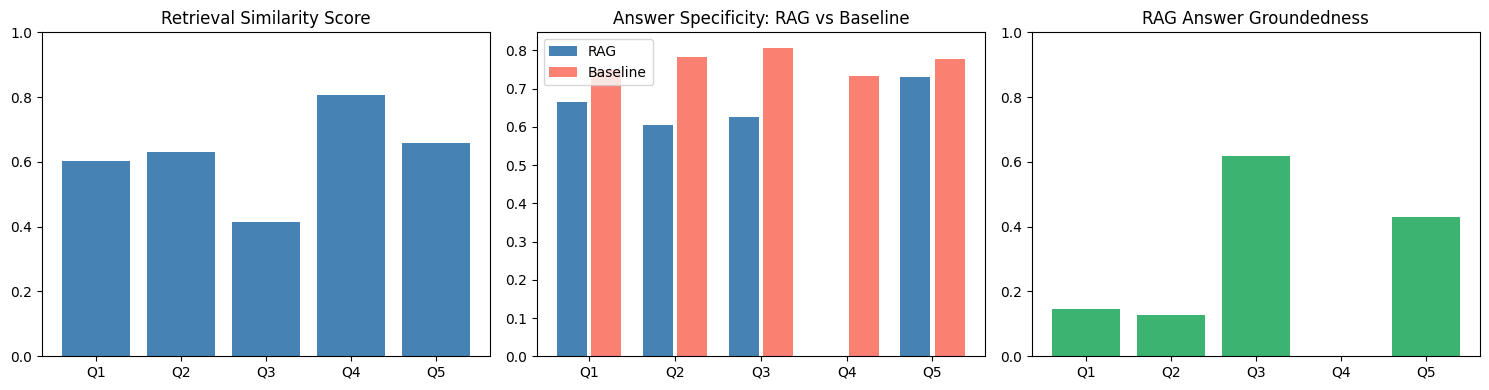

RAG evaluation complete.


In [34]:
# Evaluation: RAG vs Baseline
def answer_specificity(text):
    """Proxy for specificity: unique-word ratio + normalised length."""
    if not text: return 0.0
    words = text.lower().split()
    return round((len(set(words))/len(words) + min(len(words)/150, 1.0)) / 2, 4)

def data_groundedness(answer, retrieved_docs):
    """TF-IDF overlap between answer and retrieved context — higher = more grounded."""
    if not answer or not retrieved_docs: return 0.0
    ctx = ' '.join([d['text'] for d in retrieved_docs])
    vec = TfidfVectorizer(stop_words='english')
    try:
        mat = vec.fit_transform([ctx, answer])
        return round(float(cosine_similarity(mat[0:1], mat[1:2])[0][0]), 4)
    except: return 0.0

rag_eval_df = pd.DataFrame([{
    'Query':            r['query'][:38] + '...',
    'Top Similarity':   r['top_similarity'],
    'RAG Specificity':  answer_specificity(r['rag_answer']),
    'Base Specificity': answer_specificity(r['baseline_answer']),
    'Groundedness':     data_groundedness(r['rag_answer'], r['retrieved'])
} for r in rag_eval_results])
display(rag_eval_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
qlabels = [f'Q{i+1}' for i in range(len(rag_eval_df))]
x = np.arange(len(qlabels))
axes[0].bar(qlabels, rag_eval_df['Top Similarity'], color='steelblue')
axes[0].set_title('Retrieval Similarity Score')
axes[0].set_ylim(0, 1)
axes[1].bar(x-.2, rag_eval_df['RAG Specificity'], .35, label='RAG', color='steelblue')
axes[1].bar(x+.2, rag_eval_df['Base Specificity'], .35, label='Baseline', color='salmon')
axes[1].set_xticks(x); axes[1].set_xticklabels(qlabels)
axes[1].set_title('Answer Specificity: RAG vs Baseline')
axes[1].legend()
axes[2].bar(qlabels, rag_eval_df['Groundedness'], color='mediumseagreen')
axes[2].set_title('RAG Answer Groundedness')
axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.savefig('eval_rag.png', dpi=150, bbox_inches='tight')
plt.show()
print('RAG evaluation complete.')

---
# Advanced Technique 3: Prompting Engineering + Chain-of-Thought (CoT)

Compares three prompt strategies for **fake review detection**:
1. **Simple prompt** – direct ask, no guidance
2. **Instruction prompt** – explicit criteria given
3. **Chain-of-Thought (CoT)** – step-by-step reasoning before verdict

Also applies **instruction prompting** for aspect-based sentiment analysis.

In [35]:
# Derive heuristic fake signals from real data
def rep_ratio(text):
    words = text.lower().split()
    return round(1 - len(set(words))/len(words), 3) if words else 0

df_flagged = df_all.copy()
df_flagged['rep_ratio']  = df_flagged['review_text'].apply(rep_ratio)
df_flagged['suspicious'] = (
    (df_flagged['word_count'] < 15) &
    (df_flagged['rating'].isin([1.0, 5.0])) &
    (df_flagged['rep_ratio'] > 0.3)
).astype(int)

# Build labelled evaluation sample
fake_s    = df_flagged[df_flagged['suspicious']==1].sample(min(12, df_flagged['suspicious'].sum()), random_state=42)
genuine_s = df_flagged[(df_flagged['suspicious']==0) & (df_flagged['word_count']>=25) & (df_flagged['rep_ratio']<0.2)].sample(12, random_state=42)
fake_s['heuristic_label']    = 'Likely Fake'
genuine_s['heuristic_label'] = 'Likely Genuine'
eval_sample = pd.concat([fake_s, genuine_s]).reset_index(drop=True)

print(f'Fake signals: {df_flagged["suspicious"].sum():,} reviews flagged ({df_flagged["suspicious"].mean()*100:.1f}%)')
print(f'Eval sample: {len(eval_sample)} reviews')
print(eval_sample['heuristic_label'].value_counts())

Fake signals: 10 reviews flagged (0.0%)
Eval sample: 22 reviews
heuristic_label
Likely Genuine    12
Likely Fake       10
Name: count, dtype: int64


In [36]:
# Three prompt strategies
def prompt_simple(text, rating, wc):
    return f'Review: "{text[:300]}"\nRating: {rating}/5 | Words: {wc}\n\nIs this review fake? Answer: FAKE or GENUINE'

def prompt_instruction(text, rating, wc, rep):
    return f"""You are a fake review detector. Use these criteria:
- Is text too short to be informative (<15 words)?
- Is language vague, generic, or repetitive?
- Is rating extreme (1 or 5★) with little justification?
- Does review mention specific product features?

Review: "{text[:300]}"
Rating: {rating}/5 | Words: {wc} | Repetition ratio: {rep}

Classification (FAKE or GENUINE only):"""

def prompt_cot(text, rating, wc, rep, username):
    return f"""You are an expert fake review analyst. Think step by step.

Review: "{text[:300]}"
Rating: {rating}/5 | Words: {wc} | Repetition: {rep} | User: {username}

Step 1 – Length & detail: Is the review long enough and specific?
Step 2 – Language: Is it generic, repetitive, or natural?
Step 3 – Rating consistency: Does the star rating match the text tone?
Step 4 – Reviewer signals: Any credibility concerns?
Step 5 – Final assessment.

VERDICT: [FAKE or GENUINE]
CONFIDENCE: [Low/Medium/High]
REASON: [one sentence]"""

def extract_verdict(response, style):
    """Parses FAKE/GENUINE verdict from model output."""
    if not response: return 'UNKNOWN'
    ru = response.upper()
    if style == 'cot':
        m = re.search(r'VERDICT:\s*(FAKE|GENUINE)', ru)
        if m: return m.group(1)
    if 'FAKE' in ru and 'GENUINE' not in ru: return 'FAKE'
    if 'GENUINE' in ru: return 'GENUINE'
    if 'FAKE' in ru: return 'FAKE'
    return 'UNKNOWN'

print('Prompt templates defined. Running detection...')
SYS = 'You are an expert at detecting fake online product reviews.'
cot_det_results = []

for _, row in eval_sample.iterrows():
    text     = str(row['review_text'])
    rating   = row['rating']
    wc       = row['word_count']
    rep      = row['rep_ratio']
    username = str(row['username']) if 'username' in row.index and pd.notna(row.get('username')) else 'unknown'
    true_lbl = row['heuristic_label']

    r_s = call_llama(prompt_simple(text, rating, wc), SYS, temperature=0.1)
    r_i = call_llama(prompt_instruction(text, rating, wc, rep), SYS, temperature=0.1)
    r_c = call_llama(prompt_cot(text, rating, wc, rep, username), SYS, temperature=0.1)

    cot_det_results.append({
        'true_label':    true_lbl,
        'simple':        extract_verdict(r_s, 'simple'),
        'instruction':   extract_verdict(r_i, 'instruction'),
        'cot':           extract_verdict(r_c, 'cot'),
        'cot_reasoning': r_c,
        'review_text':   text[:80]
    })

cot_res_df = pd.DataFrame(cot_det_results)
print('Detection complete.')
display(cot_res_df[['true_label','simple','instruction','cot','review_text']].head(10))

Prompt templates defined. Running detection...
Groq API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kshzyg83f8ab7wtfg7rrwtkt` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5403, Requested 682. Please try again in 850ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Groq API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kshzyg83f8ab7wtfg7rrwtkt` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5283, Requested 797. Please try again in 800ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Detection complete.


,true_label,simple,instruction,cot,review_text
0,Likely Fake,FAKE,FAKE,FAKE,I have time to do what I have to do just becau...
1,Likely Fake,GENUINE,FAKE,GENUINE,Thank you for the gifts and thank you for the ...
2,Likely Fake,GENUINE,FAKE,FAKE,Love it love it love it love it love it love i...
3,Likely Fake,UNKNOWN,FAKE,FAKE,I Luke it a lot and good to for it for and goo...
4,Likely Fake,GENUINE,FAKE,FAKE,Dad loves it love love love it love it love it...
5,Likely Fake,GENUINE,FAKE,FAKE,Great value. Easy to use. Fun to use. Easy to ...
6,Likely Fake,GENUINE,FAKE,FAKE,I love everything about it I really enjoy it I...
7,Likely Fake,GENUINE,FAKE,FAKE,"Works Great , Great Item , Easy to Use & Easy ..."
8,Likely Fake,GENUINE,FAKE,FAKE,"Very good price and very good and nice table, ..."
9,Likely Fake,GENUINE,FAKE,FAKE,great tablet and very easy to use. very easy t...


,Accuracy,Precision,Recall,F1
Simple,0.476,0.250,0.111,0.154
Instruction,0.909,0.833,1.000,0.909
Chain-of-Thought,0.714,0.643,0.900,0.750


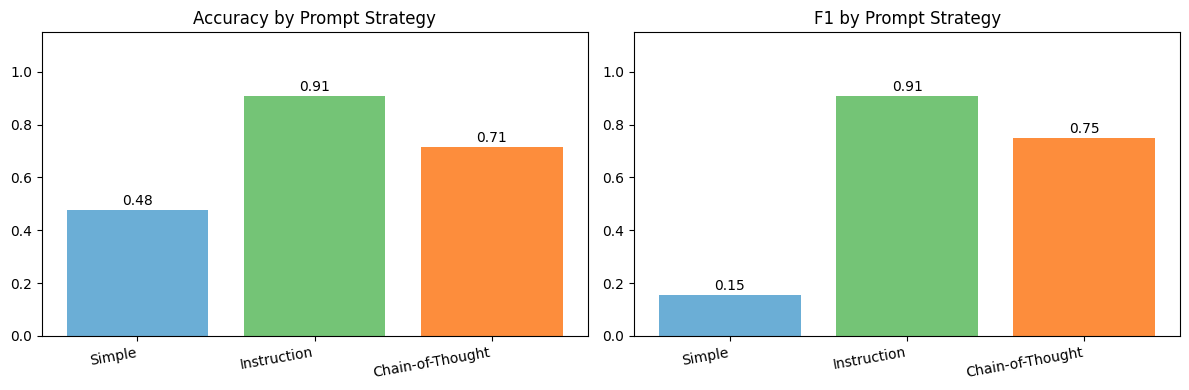

In [37]:
# Evaluate all three prompt strategies
def evaluate_detection(df, pred_col):
    label_map = {'Likely Fake': 'FAKE', 'Likely Genuine': 'GENUINE'}
    valid = df[df[pred_col] != 'UNKNOWN'].copy()
    valid['true_mapped'] = valid['true_label'].map(label_map)
    correct = (valid[pred_col] == valid['true_mapped']).sum()
    acc = correct / len(valid) if len(valid) else 0
    tp = ((valid[pred_col]=='FAKE') & (valid['true_mapped']=='FAKE')).sum()
    fp = ((valid[pred_col]=='FAKE') & (valid['true_mapped']=='GENUINE')).sum()
    fn = ((valid[pred_col]=='GENUINE') & (valid['true_mapped']=='FAKE')).sum()
    prec = tp/(tp+fp) if (tp+fp) else 0
    rec  = tp/(tp+fn) if (tp+fn) else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    return {'Accuracy': round(acc,3), 'Precision': round(prec,3), 'Recall': round(rec,3), 'F1': round(f1,3)}

perf = {'Simple': evaluate_detection(cot_res_df,'simple'),
        'Instruction': evaluate_detection(cot_res_df,'instruction'),
        'Chain-of-Thought': evaluate_detection(cot_res_df,'cot')}
perf_df = pd.DataFrame(perf).T
display(perf_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#6baed6','#74c476','#fd8d3c']
for ax, metric in zip(axes, ['Accuracy','F1']):
    vals = [perf[m][metric] for m in perf]
    bars = ax.bar(list(perf.keys()), vals, color=colors)
    ax.set_title(f'{metric} by Prompt Strategy')
    ax.set_ylim(0, 1.15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v:.2f}', ha='center')
    ax.set_xticklabels(list(perf.keys()), rotation=10, ha='right')
plt.tight_layout()
plt.savefig('eval_cot_prompting.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Aspect-Based Sentiment Analysis (Instruction Prompting)

Electronics reviews selected: 15
name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                     4
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta    2
Brand New Amazon Kindle Fire 16gb 7" Ips Display Tablet Wifi 16 Gb Blue                    2
All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case            1
Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen                            1
Name: count, dtype: int64


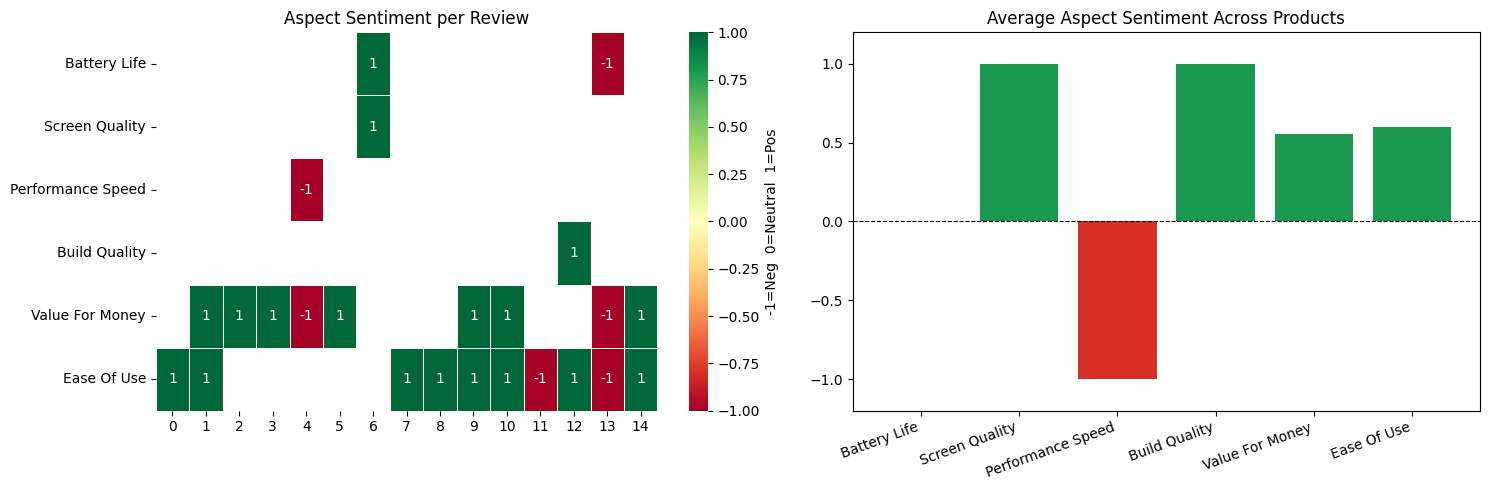

Aspect sentiment analysis complete.


In [38]:
# Select electronics reviews and sample from that filtered subset
electronics_mask = df_all['name'].str.lower().str.contains('fire|kindle|echo|alexa|tablet|ebook', na=False)
electronics      = df_all[electronics_mask].copy().reset_index(drop=True)
electronics      = electronics.sample(min(15, len(electronics)), random_state=42).reset_index(drop=True)

print(f'Electronics reviews selected: {len(electronics)}')
print(electronics['name'].value_counts().head(5))

ASPECTS  = ['battery_life','screen_quality','performance_speed','build_quality','value_for_money','ease_of_use']
SENT_MAP = {'Positive':1, 'Neutral':0, 'Negative':-1, 'Not_Mentioned': None}
asp_results = []

for _, row in electronics.iterrows():
    prompt = f"""Review: "{str(row['review_text'])[:400]}"
Extract sentiment for each aspect: Positive, Negative, Neutral, or Not_Mentioned.
Respond ONLY as JSON:
{{"battery_life":"...","screen_quality":"...","performance_speed":"...","build_quality":"...","value_for_money":"...","ease_of_use":"..."}}"""
    response = call_llama(prompt, temperature=0.1)
    try:
        jm = re.search(r'\{.*\}', response or '', re.DOTALL)
        parsed = json.loads(jm.group()) if jm else {}
    except Exception:
        parsed = {}
    row_data = {'product': row['name'][:40], 'rating': row['rating']}
    for asp in ASPECTS:
        row_data[asp] = SENT_MAP.get(parsed.get(asp, 'Not_Mentioned'), None)
    asp_results.append(row_data)

asp_df = pd.DataFrame(asp_results)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(asp_df[ASPECTS].astype(float).T, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.0f', linewidths=0.5, ax=axes[0],
            cbar_kws={'label': '-1=Neg  0=Neutral  1=Pos'})
axes[0].set_title('Aspect Sentiment per Review')
axes[0].set_yticklabels([a.replace('_',' ').title() for a in ASPECTS], rotation=0)
avg_asp = {a: asp_df[a].dropna().mean() for a in ASPECTS}
cols    = ['#1a9850' if v > 0.1 else '#d73027' if v < -0.1 else '#fdae61' for v in avg_asp.values()]
axes[1].bar([a.replace('_',' ').title() for a in ASPECTS], list(avg_asp.values()), color=cols)
axes[1].set_title('Average Aspect Sentiment Across Products')
axes[1].set_ylim(-1.2, 1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticklabels([a.replace('_',' ').title() for a in ASPECTS], rotation=20, ha='right')
plt.tight_layout()
plt.savefig('eval_aspect_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Aspect sentiment analysis complete.')


---
# Advanced Technique 4: Agentic Design

An autonomous agent that **plans** which tools to run and **executes** them in sequence:
- **Tool A** – Fake detector (CoT prompting)
- **Tool B** – Sentiment analyser (instruction prompting)
- **Tool C** – RAG retriever (semantic search on reviews)
- **Tool D** – Report generator (Llama summarisation)

This ties all 4 advanced techniques into a single unified pipeline.

In [39]:
# ═══ TOOL A: Fake Detector ═══════════════════════════════════════════════
def tool_fake_detector(reviews_df):
    """Flags suspicious reviews using heuristics + LLM CoT on top candidates."""
    df = reviews_df.copy()
    total = len(df)

    # Recalculate fake signals on whatever df is passed in
    if 'word_count' not in df.columns:
        df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
    def _rep(text):
        w = str(text).lower().split()
        return round(1 - len(set(w))/len(w), 3) if w else 0
    df['rep_ratio']  = df['review_text'].apply(_rep)
    df['suspicious'] = (
        (df['word_count'] < 15) &
        (df['rating'].isin([1.0, 5.0])) &
        (df['rep_ratio'] > 0.3)
    ).astype(int)

    h_flags        = int(df['suspicious'].sum())
    top_suspicious = df[df['suspicious'] == 1].head(5)
    llm_flags = []

    for _, row in top_suspicious.iterrows():
        prompt = f"""Review: "{str(row['review_text'])[:250]}"
Rating: {row['rating']}/5 | Words: {row['word_count']}
Step 1: Is it too short? Step 2: Generic language? Step 3: Rating justified?
VERDICT: [FAKE or GENUINE]
CONFIDENCE: [Low/Medium/High]"""
        resp = call_llama(prompt, 'You are a fake review expert.', temperature=0.1) or ''
        vm   = re.search(r'VERDICT:\s*(FAKE|GENUINE)', resp.upper())
        cm   = re.search(r'CONFIDENCE:\s*(\w+)', resp, re.IGNORECASE)
        llm_flags.append({
            'review':     str(row['review_text'])[:80],
            'verdict':    vm.group(1) if vm else 'UNKNOWN',
            'confidence': cm.group(1) if cm else 'Unknown'
        })

    return {
        'total_reviews':        total,
        'heuristic_suspicious': h_flags,
        'llm_confirmed_fake':   sum(1 for f in llm_flags if f['verdict'] == 'FAKE'),
        'fake_rate_pct':        round(h_flags / total * 100, 1),
        'flagged_details':      llm_flags
    }


# ═══ TOOL B: Sentiment Analyser ══════════════════════════════════════════════
def tool_sentiment_analyser(reviews_df, n_sample=10):
    """Extracts overall stats and aspect-level sentiment for a product."""
    sample     = reviews_df[reviews_df['word_count'] >= 15].sample(
                     min(n_sample, len(reviews_df[reviews_df['word_count'] >= 15])), random_state=42)
    avg_r      = reviews_df['rating'].mean()
    pct_pos    = (reviews_df['rating'] >= 4).mean() * 100
    pct_neg    = (reviews_df['rating'] <= 2).mean() * 100
    aspects    = ['battery_life', 'performance', 'build_quality', 'value', 'usability']
    asp_totals = {a: [] for a in aspects}
    s_map      = {'Positive': 1, 'Neutral': 0, 'Negative': -1, 'Not_Mentioned': None}

    for _, row in sample.iterrows():
        prompt = (f'Review: "{str(row["review_text"])[:300]}"\n'
                  f'For each aspect give: Positive/Negative/Neutral/Not_Mentioned.\n'
                  f'JSON only: {{"battery_life":"...","performance":"...","build_quality":"...","value":"...","usability":"..."}}' )
        resp = call_llama(prompt, 'You are a sentiment analyst.', temperature=0.1)
        try:
            jm     = re.search(r'\{.*\}', resp or '', re.DOTALL)
            parsed = json.loads(jm.group()) if jm else {}
        except Exception:
            parsed = {}
        for asp in aspects:
            v = s_map.get(parsed.get(asp, 'Not_Mentioned'), None)
            if v is not None:
                asp_totals[asp].append(v)

    return {
        'avg_rating':    round(avg_r, 2),
        'pct_positive':  round(pct_pos, 1),
        'pct_negative':  round(pct_neg, 1),
        'aspect_scores': {a: round(np.mean(v), 3) if v else 0.0 for a, v in asp_totals.items()}
    }


# ═══ TOOL C: RAG Retriever ════════════════════════════════════════════════════
def tool_rag_retriever(query, top_k=4):
    """Uses the ChromaDB collection built in Section 2 for retrieval."""
    q_emb   = embedder.encode([query]).tolist()
    results = collection.query(query_embeddings=q_emb, n_results=top_k)
    return '\n\n'.join(results['documents'][0])


# ═══ TOOL D: Report Generator ═════════════════════════════════════════════════
def tool_report_generator(product_name, fake_r, sent_r, rag_ctx):
    """Synthesises all tool outputs into a structured business report via Llama."""
    system = 'You are a senior e-commerce business analyst. Be concise and data-driven.'
    prompt = (f'Product: {product_name[:70]}\n'
              f'REVIEW AUTHENTICITY: {fake_r["heuristic_suspicious"]} suspicious / '
              f'{fake_r["total_reviews"]} total ({fake_r["fake_rate_pct"]}%)\n'
              f'SENTIMENT: Avg {sent_r["avg_rating"]}★ | {sent_r["pct_positive"]}% positive | '
              f'{sent_r["pct_negative"]}% negative\n'
              f'ASPECT SCORES: {sent_r["aspect_scores"]}\n'
              f'CUSTOMER CONTEXT (from reviews):\n{rag_ctx[:600]}\n\n'
              f'Write a business intelligence report:\n'
              f'1. Product Health Score (1-10)\n'
              f'2. Review Authenticity Assessment\n'
              f'3. Top 2 customer strengths\n'
              f'4. Top 2 customer pain points\n'
              f'5. Three specific seller recommendations')
    return call_llama(prompt, system_prompt=system, temperature=0.3)


print('All 4 agent tools defined.')


All 4 agent tools defined.


In [40]:
from datetime import datetime

class EcommerceAgent:
    """
    Autonomous e-commerce intelligence agent.
    Follows a ReAct-style loop:
    Observe (product + reviews) → Think (plan tools) → Act (run tools) → Report
    """
    def __init__(self): self.log = []

    def _log(self, step, tool, summary):
        entry = {'step': step, 'tool': tool, 'summary': str(summary)[:100],
                 'time': datetime.now().strftime('%H:%M:%S')}
        self.log.append(entry)
        print(f'  [{entry["time"]}] Step {step} | {tool} → {str(summary)[:70]}')

    def plan(self, product_name, n_reviews):
        """Uses Llama to decide which tools to run and in what order."""
        prompt = f"""Task: Analyse '{product_name[:50]}' with {n_reviews} reviews.
Available tools: [fake_detector, sentiment_analyser, rag_retriever, report_generator]
List tools in execution order (one per line, names only):"""
        resp = call_llama(prompt, temperature=0.1) or ''
        tool_map = {'fake':'fake_detector','sentiment':'sentiment_analyser',
                    'rag':'rag_retriever','report':'report_generator'}
        plan = []
        for line in resp.split('\n'):
            for key, name in tool_map.items():
                if key in line.lower() and name not in plan:
                    plan.append(name)
        if not plan or 'report_generator' not in plan:
            plan = ['fake_detector','sentiment_analyser','rag_retriever','report_generator']
        elif plan[-1] != 'report_generator':
            plan = [t for t in plan if t != 'report_generator'] + ['report_generator']
        return plan

    def run(self, product_name, full_df):
        """Runs the full plan-and-execute loop for a single product."""
        self.log = []
        prod_df  = full_df[full_df['name'].str.contains(product_name[:30], case=False, na=False)].copy()
        if prod_df.empty:
            print(f'No reviews found for: {product_name}')
            return None

        print(f'\n{"="*65}')
        print(f'Agent: {product_name[:60]}')
        print(f'Reviews: {len(prod_df)} | {"="*30}')

        plan  = self.plan(product_name, len(prod_df))
        print(f'Plan: {plan}')

        step = 1
        fake_r, sent_r, rag_ctx, report = None, None, '', ''

        for tool in plan:
            if tool == 'fake_detector':
                fake_r = tool_fake_detector(prod_df)
                self._log(step, tool, f"{fake_r['heuristic_suspicious']} suspicious / {fake_r['total_reviews']} total")
            elif tool == 'sentiment_analyser':
                sent_r = tool_sentiment_analyser(prod_df)
                self._log(step, tool, f"Avg {sent_r['avg_rating']}★ | {sent_r['pct_positive']}% positive")
            elif tool == 'rag_retriever':
                rag_ctx = tool_rag_retriever(f'{product_name} customer feedback issues')
                self._log(step, tool, f'Retrieved {len(rag_ctx.split())} words')
            elif tool == 'report_generator' and fake_r and sent_r:
                report = tool_report_generator(product_name, fake_r, sent_r, rag_ctx)
                self._log(step, tool, 'Report generated')
            step += 1

        return {'product': product_name, 'n_reviews': len(prod_df), 'plan': plan,
                'fake_r': fake_r, 'sent_r': sent_r, 'report': report, 'agent_log': self.log}


# Run agent on top 3 products
agent       = EcommerceAgent()
top_3       = df_all['name'].value_counts().head(3).index.tolist()
all_outputs = []
for product in top_3:
    out = agent.run(product, df_all)
    if out: all_outputs.append(out)


Agent: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer
Reviews: 12204 | ==============================
Plan: ['fake_detector', 'sentiment_analyser', 'rag_retriever', 'report_generator']
  [04:00:40] Step 1 | fake_detector → 7 suspicious / 12204 total
  [04:00:55] Step 2 | sentiment_analyser → Avg 4.46★ | 90.8% positive
  [04:00:55] Step 3 | rag_retriever → Retrieved 118 words
  [04:01:02] Step 4 | report_generator → Report generated

Agent: AmazonBasics AAA Performance Alkaline Batteries (36 Count)
Reviews: 4275 | ==============================
Plan: ['fake_detector', 'sentiment_analyser', 'rag_retriever', 'report_generator']
  [04:01:04] Step 1 | fake_detector → 0 suspicious / 4275 total
  [04:01:20] Step 2 | sentiment_analyser → Avg 4.24★ | 80.1% positive
  [04:01:20] Step 3 | rag_retriever → Retrieved 141 words
  [04:01:24] Step 4 | report_generator → Report generated
No reviews found for: Echo (White)


In [41]:
# Display intelligence reports
for out in all_outputs:
    display(Markdown(f'---\n## Intelligence Report: {out["product"][:70]}'))
    display(Markdown(out['report'] or '*No report generated*'))

# Agent execution log
print('\n=== Agent Execution Log ===')
for out in all_outputs:
    print(f'\nProduct: {out["product"][:60]}')
    display(pd.DataFrame(out['agent_log'])[['step','tool','time','summary']])

---
## Intelligence Report: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta

**Business Intelligence Report: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers**

**1. Product Health Score (1-10)**

Based on the sentiment analysis and aspect scores, I would assign a Product Health Score of 6 out of 10. The tablet has received mostly positive reviews (90.8%), but there are concerns about battery life, performance, and build quality.

**2. Review Authenticity Assessment**

The review authenticity assessment indicates that 7 out of 12204 reviews are suspicious (0.1%). This is a relatively low rate, suggesting that the reviews are generally authentic.

**3. Top 2 Customer Strengths**

Based on the customer context, the top 2 customer strengths are:

1. **Value**: Customers appreciate the great price of the product, with one reviewer stating "great item and at a great price."
2. **Usability**: Customers enjoy using the tablet daily, with one reviewer stating "love using it daily."

**4. Top 2 Customer Pain Points**

Based on the customer context, the top 2 customer pain points are:

1. **Performance**: Customers have reported issues with the tablet's performance, including slowness and unreliability.
2. **Build Quality**: Customers have reported issues with the tablet's build quality, including a faulty charging port.

**5. Three Specific Seller Recommendations**

Based on the customer feedback, I recommend the following:

1. **Improve Performance**: Consider upgrading the tablet's processor or optimizing the software to improve performance and reduce slowness.
2. **Enhance Build Quality**: Consider using higher-quality materials or redesigning the charging port to prevent faults.
3. **Provide Better Customer Support**: Consider offering more comprehensive customer support, including troubleshooting guides and repair options, to help customers resolve issues with the tablet.

By addressing these pain points and strengthening the product's performance and build quality, the seller can improve customer satisfaction and increase loyalty.

---
## Intelligence Report: AmazonBasics AAA Performance Alkaline Batteries (36 Count)

**Business Intelligence Report: AmazonBasics AAA Performance Alkaline Batteries (36 Count)**

**Product Health Score: 8/10**

Based on the provided data, the product has an average rating of 4.24/5 and 80.1% positive reviews, indicating a high level of customer satisfaction. However, the negative reviews (14.6%) and low usability aspect score (0.0) suggest areas for improvement.

**Review Authenticity Assessment: 100%**

The review authenticity assessment indicates that 0 out of 4275 reviews are suspicious, suggesting that the reviews are genuine and trustworthy.

**Top 2 Customer Strengths:**

1. **Value**: Customers appreciate the value offered by AmazonBasics AAA Performance Alkaline Batteries, with many reviewers mentioning that they are a "real steal" compared to store-bought batteries.
2. **Performance**: The batteries are praised for their performance, with many reviewers giving them a perfect 5-star rating.

**Top 2 Customer Pain Points:**

1. **Usability**: The low usability aspect score (0.0) suggests that some customers may have difficulty using the batteries or have had issues with their performance in certain devices.
2. **Build Quality**: The build quality aspect score (0.333) is relatively low, indicating that some customers may have concerns about the durability or construction of the batteries.

**Three Specific Seller Recommendations:**

1. **Improve Usability**: Consider adding clear instructions or guidelines on how to use the batteries effectively, or providing additional information on compatible devices.
2. **Enhance Build Quality**: Investigate ways to improve the durability and construction of the batteries, such as using higher-quality materials or redesigning the packaging.
3. **Increase Transparency**: Provide more detailed information on the battery's specifications, such as shelf life, storage conditions, and compatibility with specific devices, to help customers make informed purchasing decisions.


=== Agent Execution Log ===

Product: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer


,step,tool,time,summary
0,1,fake_detector,04:00:40,7 suspicious / 12204 total
1,2,sentiment_analyser,04:00:55,Avg 4.46★ | 90.8% positive
2,3,rag_retriever,04:00:55,Retrieved 118 words
3,4,report_generator,04:01:02,Report generated



Product: AmazonBasics AAA Performance Alkaline Batteries (36 Count)


,step,tool,time,summary
0,1,fake_detector,04:01:04,0 suspicious / 4275 total
1,2,sentiment_analyser,04:01:20,Avg 4.24★ | 80.1% positive
2,3,rag_retriever,04:01:20,Retrieved 141 words
3,4,report_generator,04:01:24,Report generated


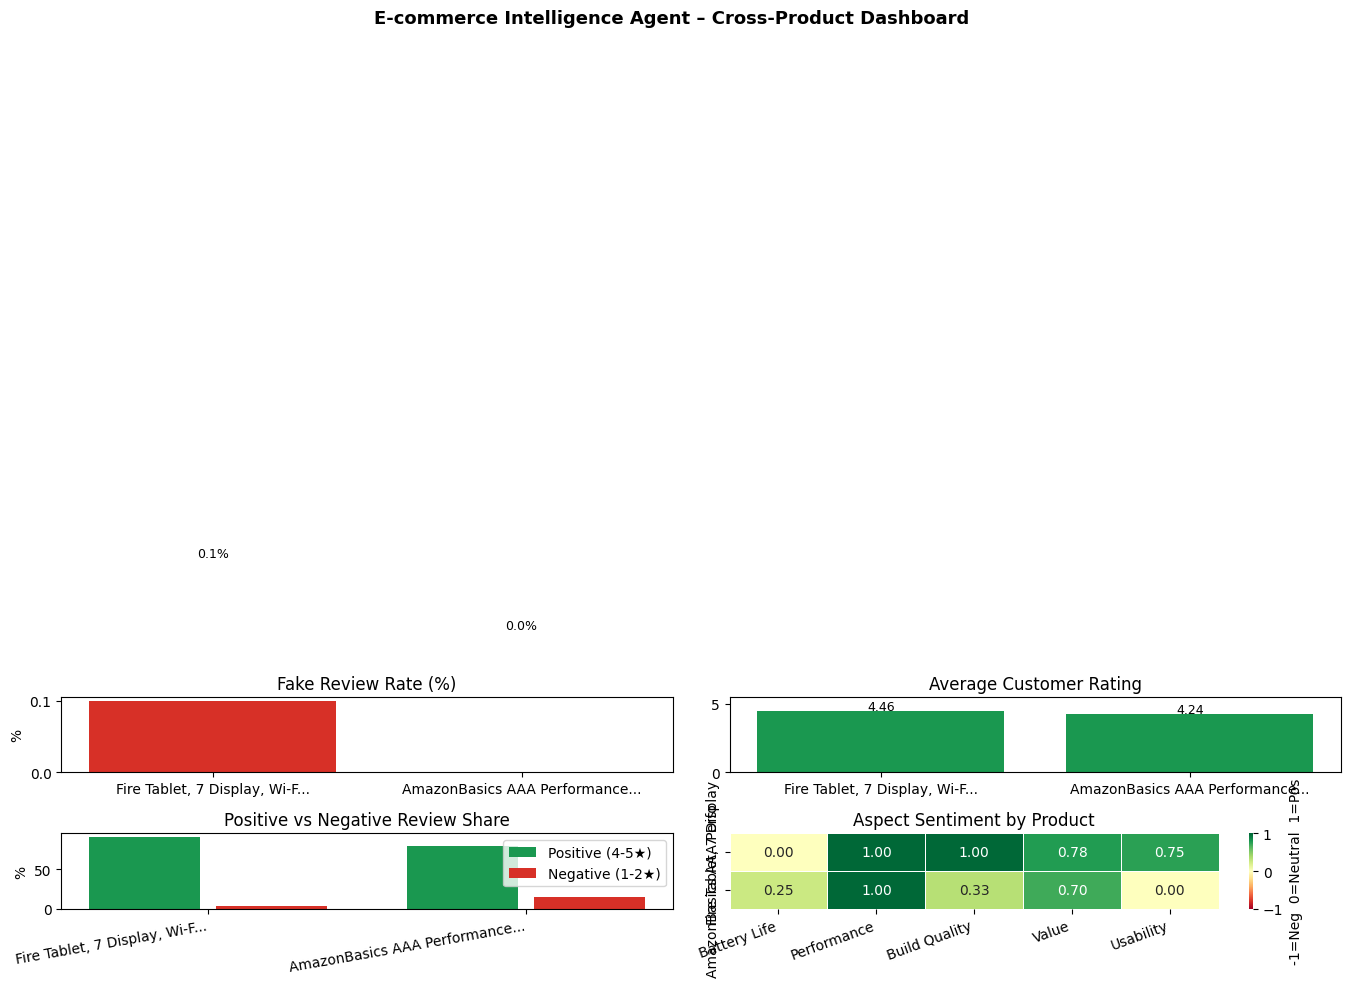

Dashboard saved.


In [42]:
# Cross-product dashboard
if all_outputs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    p_labels  = [o['product'][:28] + '...' for o in all_outputs]

    fake_rates = [o['fake_r']['fake_rate_pct'] for o in all_outputs if o['fake_r']]
    axes[0,0].bar(p_labels[:len(fake_rates)], fake_rates, color='#d73027')
    axes[0,0].set_title('Fake Review Rate (%)')
    axes[0,0].set_ylabel('%')
    for i,v in enumerate(fake_rates): axes[0,0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=9)

    avg_ratings = [o['sent_r']['avg_rating'] for o in all_outputs if o['sent_r']]
    bar_colors  = ['#1a9850' if r>=4 else '#fdae61' if r>=3 else '#d73027' for r in avg_ratings]
    axes[0,1].bar(p_labels[:len(avg_ratings)], avg_ratings, color=bar_colors)
    axes[0,1].set_title('Average Customer Rating')
    axes[0,1].set_ylim(0, 5.5)
    for i,v in enumerate(avg_ratings): axes[0,1].text(i, v+0.1, f'{v:.2f}', ha='center', fontsize=9)

    x       = np.arange(len(all_outputs))
    pct_pos = [o['sent_r']['pct_positive'] for o in all_outputs if o['sent_r']]
    pct_neg = [o['sent_r']['pct_negative'] for o in all_outputs if o['sent_r']]
    axes[1,0].bar(x-.2, pct_pos[:len(x)], .35, label='Positive (4-5★)', color='#1a9850')
    axes[1,0].bar(x+.2, pct_neg[:len(x)], .35, label='Negative (1-2★)', color='#d73027')
    axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(p_labels[:len(x)], rotation=10, ha='right')
    axes[1,0].set_title('Positive vs Negative Review Share')
    axes[1,0].set_ylabel('%')
    axes[1,0].legend()

    asp_data = [o['sent_r']['aspect_scores'] for o in all_outputs if o['sent_r']]
    if asp_data:
        asp_plot = pd.DataFrame(asp_data, index=[o['product'][:22] for o in all_outputs[:len(asp_data)]])
        sns.heatmap(asp_plot, cmap='RdYlGn', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
                    linewidths=0.5, ax=axes[1,1], cbar_kws={'label': '-1=Neg  0=Neutral  1=Pos'})
        axes[1,1].set_title('Aspect Sentiment by Product')
        axes[1,1].set_xticklabels([a.replace('_',' ').title() for a in asp_plot.columns], rotation=20, ha='right')

    plt.suptitle('E-commerce Intelligence Agent – Cross-Product Dashboard', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('agent_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Dashboard saved.')

---
# Project Summary

| Advanced Technique | Implementation | Evaluation Metric |
|---|---|---|
| LLM Foundation (Llama 3.1) | Review summarisation, description generation, business insights | TF-IDF Coverage, Unigram Recall |
| RAG | ChromaDB vector store + sentence-transformers retrieval | Retrieval similarity, Groundedness, Specificity |
| CoT Prompting | Fake detection (3 strategies), aspect sentiment | Accuracy, Precision, Recall, F1 |
| Agentic Design | Plan-and-execute pipeline across all tools | Execution log, Cross-product dashboard |

**Dataset:** Datafiniti Amazon Consumer Reviews (~67,000 reviews combined from 3 CSVs)

**Model:** Llama 3.1-8b-instant via Groq API (free tier)

**Plots saved:** `nb1_rating_distribution.png`, `eval_llm_foundation.png`, `eval_rag.png`, `eval_cot_prompting.png`, `eval_aspect_sentiment.png`, `agent_dashboard.png`